In [65]:
import pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt, seaborn as sns
url = "https://raw.githubusercontent.com/nkmwicz/worldcup2018data/refs/heads/main/cleaned_events_world_cup2018.csv"
df = pd.read_csv(url)
for col in df.columns:
    print(col)
df.head(1)

eventId
subEventName
tags
playerId
matchId
eventName
teamId
matchPeriod
eventSec
subEventId
id
x1
y1
x2
y2


,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0


In [66]:
import ast
df["tags"] = df["tags"].apply(ast.literal_eval)

In [67]:
ast.literal_eval


<function ast.literal_eval(node_or_string)>

In [68]:
df["subEventName"].unique

<bound method Series.unique of 0                     Simple pass
1                       High pass
2                        Air duel
3                        Air duel
4                     Simple pass
                   ...           
101754                Simple pass
101755                      Touch
101756                      Cross
101757    Goalkeeper leaving line
101758                     Launch
Name: subEventName, Length: 101759, dtype: object>

In [69]:
uniquetags = set()
for taglist in df["tags"]: 
    for tag in taglist:
        print(tag)
        uniquetags.add(tag)

uniquetags = {tag for taglist in df["tags"] for tag in taglist}
uniquetags

Accurate
Accurate
Won
Accurate
Lost
Not accurate
Accurate
Accurate
Free space right
Won
Accurate
Accurate
Accurate
Accurate
Accurate
Take on right
Neutral
Accurate
Take on left
Neutral
Accurate
Accurate
Free space left
Lost
Not accurate
Free space right
Won
Accurate
Accurate
Not accurate
Not accurate
Take on right
Won
Accurate
Take on left
Lost
Not accurate
Accurate
Accurate
Accurate
Accurate
Lost
Not accurate
Won
Accurate
Not accurate
Accurate
Accurate
Accurate
Free space left
Lost
Not accurate
Free space right
Won
Accurate
Not accurate
Not accurate
Missed ball
Free space right
Anticipation
Won
Accurate
Free space left
Anticipated
Lost
Not accurate
Accurate
Lost
Not accurate
Won
Accurate
Take on left
Won
Accurate
Take on right
Lost
Not accurate
Not accurate
Accurate
Accurate
Accurate
Accurate
Neutral
Accurate
Neutral
Accurate
High
Not accurate
Interception
Not accurate
Accurate
Accurate
Accurate
Won
Accurate
Lost
Not accurate
Accurate
Anticipated
Lost
Not accurate
Anticipation
Lost
No

{'Accurate',
 'Anticipated',
 'Anticipation',
 'Assist',
 'Blocked',
 'Counter attack',
 'Dangerous ball lost',
 'Direct',
 'Fairplay',
 'Feint',
 'Free space left',
 'Free space right',
 'Goal',
 'Head/body',
 'High',
 'Indirect',
 'Interception',
 'Key pass',
 'Left foot',
 'Lost',
 'Missed ball',
 'Neutral',
 'Not accurate',
 'Opportunity',
 'Own goal',
 'Position: Goal center',
 'Position: Goal center left',
 'Position: Goal center right',
 'Position: Goal high center',
 'Position: Goal high left',
 'Position: Goal high right',
 'Position: Goal low center',
 'Position: Goal low left',
 'Position: Goal low right',
 'Position: Out center left',
 'Position: Out center right',
 'Position: Out high center',
 'Position: Out high left',
 'Position: Out high right',
 'Position: Out low left',
 'Position: Out low right',
 'Position: Post center left',
 'Position: Post center right',
 'Position: Post high center',
 'Position: Post high left',
 'Position: Post high right',
 'Position: Post lo

In [70]:
#passes, shots, goals, acc_passes, golden_shots 
df['pass'] = (df['eventName'] == "Pass").astype(int)
df['shot'] = (df['eventName'] == "Shot").astype(int)
# rows eventName == shot and Goal is in tags
df['goal'] = ((df['eventName'] == "Shot") & (df["tags"].apply(lambda l: "Goal" in l))).astype(int)
# acc_pass = rows where eventName is pass and Accurate is in tags
df['acc_pass'] = ((df['eventName'] == "Pass") & (df["tags"].apply(lambda l: "Accurate" in l))).astype(int)
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,pass,shot,goal,acc_pass
0,8,Simple pass,[Accurate],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0,1,0,0,1


In [71]:
from math import dist
# Golden Events are events that take place within 18 yards of goal center
# convert Xs and Ys to yards
# is distance from (x1, y1) to goal center (120, 37.5) Less/equal to 18
# use euclidian distance algorithms (math.dist())
def get_gold_events(row:pd.Series):
    x_len = 120
    y_len = 70
    x1 = (row["x1"] / 100) * x_len
    y1 = (row["y1"] / 100) * y_len
    x2 = x_len
    y2 = y_len / 2
    point1 = [x1,y1]
    point2 = [x2,y2]
    d = dist(point1,point2)
    if d <=18:
        return 1
    else:
        return 0

df['gold_event'] = df.apply(get_gold_events, axis=1)
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,pass,shot,goal,acc_pass,gold_event
0,8,Simple pass,[Accurate],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0,1,0,0,1,0


In [72]:
df['gold_shot'] = ((df['shot'] == 1) & (df['gold_event'] ==1)).astype(int)
df['gold_pass'] = ((df['pass'] == 1) & (df['gold_event'] ==1)).astype(int)

In [73]:
grp = df.groupby(["matchId", "teamId"]).agg(
    shots=("shot", "sum"),
    gold_shots=("gold_shot", "sum"),
    goals=("goal", "sum"),
    passes=("pass", "sum"),
    acc_passes=("acc_pass", "sum"),
    gold_passes=("gold_pass", "sum"),
    gold_events=("gold_event", "sum"),
).reset_index()
grp["perc_acc_pass"] = grp["acc_passes"] / grp["passes"]
grp["perc_gold_shot"] = grp["gold_shots"] / grp["shots"]
grp

,matchId,teamId,shots,gold_shots,goals,passes,acc_passes,gold_passes,gold_events,perc_acc_pass,perc_gold_shot
0,"Argentina - Croatia, 0 - 3",Argentina,10,7,0,476,393,4,24,0.825630,0.700000
1,"Argentina - Croatia, 0 - 3",Croatia,13,5,3,334,261,4,19,0.781437,0.384615
2,"Argentina - Iceland, 1 - 1",Argentina,22,6,1,744,675,5,32,0.907258,0.272727
3,"Argentina - Iceland, 1 - 1",Iceland,8,3,1,183,141,2,17,0.770492,0.375000
4,"Australia - Peru, 0 - 2",Australia,11,8,0,512,446,6,37,0.871094,0.727273
...,...,...,...,...,...,...,...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,6,1,2,238,185,0,9,0.777311,0.166667
124,"Uruguay - Russia, 3 - 0",Russia,3,0,0,327,271,2,8,0.828746,0.000000
125,"Uruguay - Russia, 3 - 0",Uruguay,12,5,1,466,405,2,16,0.869099,0.416667
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,7,2,0,553,482,2,11,0.871609,0.285714


In [74]:
def viz_corr(df:pd.DataFrame, x:str, y:str) -> None:
    plt.figure(figsize=(5,3))
    xlabel = x.replace("_", " ").title()
    ylabel = y.replace("_", " ").title()
    title = f"Correlation between {xlabel} and {ylabel}"
    r, p = stats.pearsonr(df[x], df[y])
    r2 = r**2
    text = f"""r: {r:.4f}
    p:{p:.4f}
    r2:{r2:.4f}"""
    reg = sns.regplot(data=df), x=x, y=y, line_kws={"color": "red", "label": "line"}
    reg.text(
        0.1,
        0.7,
        text,
        transform=reg.transAxes,
        bbox={"boxstyle": "round,pad=0.5", "fc": "white"}
    )
    reg.set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.legend()
    plt.show()

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (2534930303.py, line 11)

In [75]:
def viz_corr(df:pd.DataFrame, x:str, y:str) -> None:
    plt.figure(figsize=(5,3))
    xlabel = x.replace("_", " ").title()
    ylabel = y.replace("_", " ").title()
    title=f"Correlation between {xlabel} and {ylabel}"
    r,p = stats.pearsonr(df[x], df[y])
    r2 = r**2
    text = f"""r: {r:.4f}
p: {p:.4f}
r2: {r2:.4f}"""
    reg = sns.regplot(data=df, x=x, y=y, line_kws={"color": "red", "label": "Line of best fit."})
    reg.text(
        0.1,
        0.7,
        text,
        transform=reg.transAxes,
        bbox={"boxstyle": "round,pad=0.5", "fc": "white"}
    )
    reg.set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.legend()
    plt.show()

In [76]:
grp.corr(numeric_only=True)


,shots,gold_shots,goals,passes,acc_passes,gold_passes,gold_events,perc_acc_pass,perc_gold_shot
shots,1.000000,0.787114,0.210675,0.564229,0.555309,0.515186,0.705135,0.392210,0.024879
gold_shots,0.787114,1.000000,0.230924,0.484080,0.478433,0.470070,0.739601,0.332407,0.552649
goals,0.210675,0.230924,1.000000,0.120015,0.125879,0.076867,0.056679,0.162325,0.164582
passes,0.564229,0.484080,0.120015,1.000000,0.995563,0.520348,0.464445,0.741263,0.058750
acc_passes,0.555309,0.478433,0.125879,0.995563,1.000000,0.511136,0.445203,0.788865,0.061737
gold_passes,0.515186,0.470070,0.076867,0.520348,0.511136,1.000000,0.688169,0.303628,0.081918
gold_events,0.705135,0.739601,0.056679,0.464445,0.445203,0.688169,1.000000,0.221705,0.264160
perc_acc_pass,0.392210,0.332407,0.162325,0.741263,0.788865,0.303628,0.221705,1.000000,0.043847
perc_gold_shot,0.024879,0.552649,0.164582,0.058750,0.061737,0.081918,0.264160,0.043847,1.000000


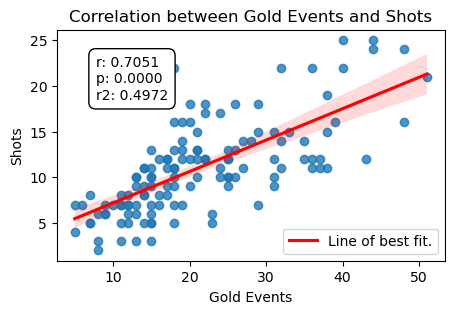

In [77]:
viz_corr(grp, "gold_events", "shots")


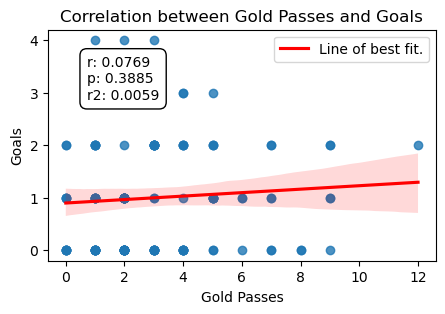

In [78]:
viz_corr(grp, "gold_passes", "goals")


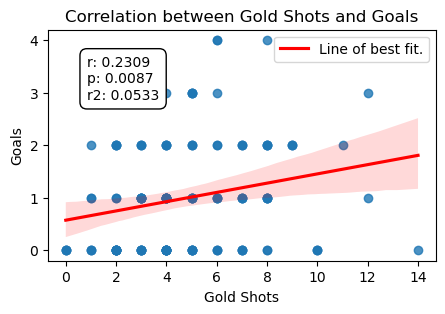

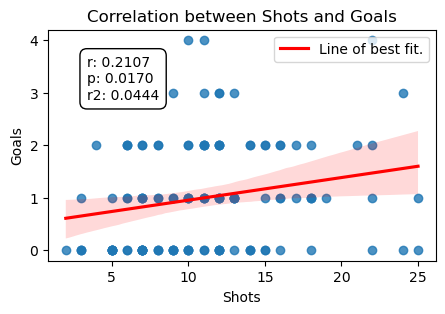

In [79]:

viz_corr(grp, "gold_shots", "goals")
viz_corr(grp, "shots", "goals")

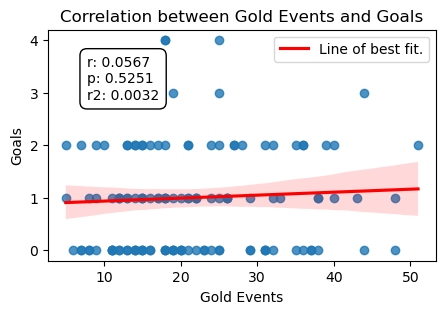

In [80]:

viz_corr(grp, "gold_events", "goals")
